## Decision Tree for classification

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [35]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [36]:
# titanic.isnull().sum()

In [37]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]


In [38]:
# Filling missing values 
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]]) # Expects 2nd array

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [39]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [40]:
# Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])


In [41]:
#titanic.head()

In [42]:
X = titanic[features]
y = titanic[target]

In [43]:
X_train,X_test , y_train , y_test  = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [44]:
# X_test.head()

In [45]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier 
model = DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
from sklearn.metrics import precision_score , accuracy_score , recall_score,f1_score
y_pred = model.predict(X_test)
# Evaluation Matrix
print("recall_score:- ",recall_score(y_test,y_pred))
print("Accuracy:- ",accuracy_score(y_test,y_pred))
print("Precision:- ",precision_score(y_test,y_pred))
print("f1_score:- ",f1_score(y_test,y_pred))

recall_score:-  0.7837837837837838
Accuracy:-  0.776536312849162
Precision:-  0.7073170731707317
f1_score:-  0.7435897435897436


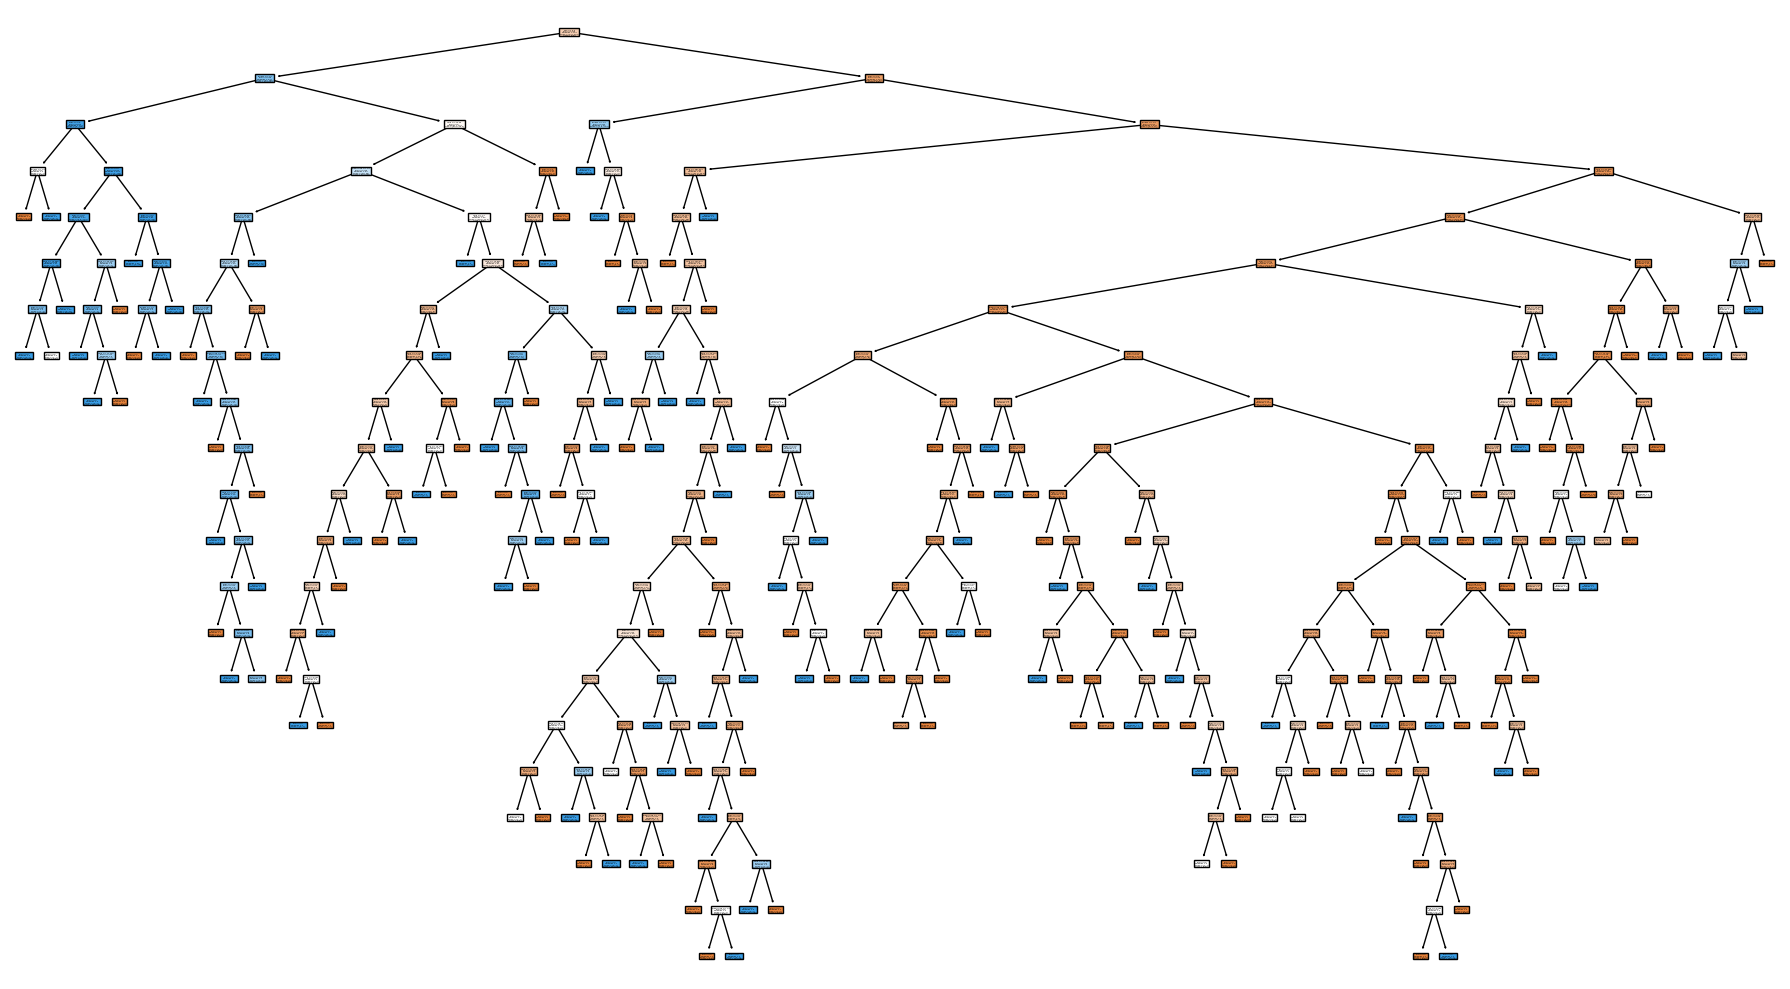

In [47]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

## Decision Tree With Pre-Prunning

for depth =1 , accuracy=0.7821229050279329
for depth =2 , accuracy=0.7653631284916201
for depth =3 , accuracy=0.7988826815642458
for depth =4 , accuracy=0.7988826815642458


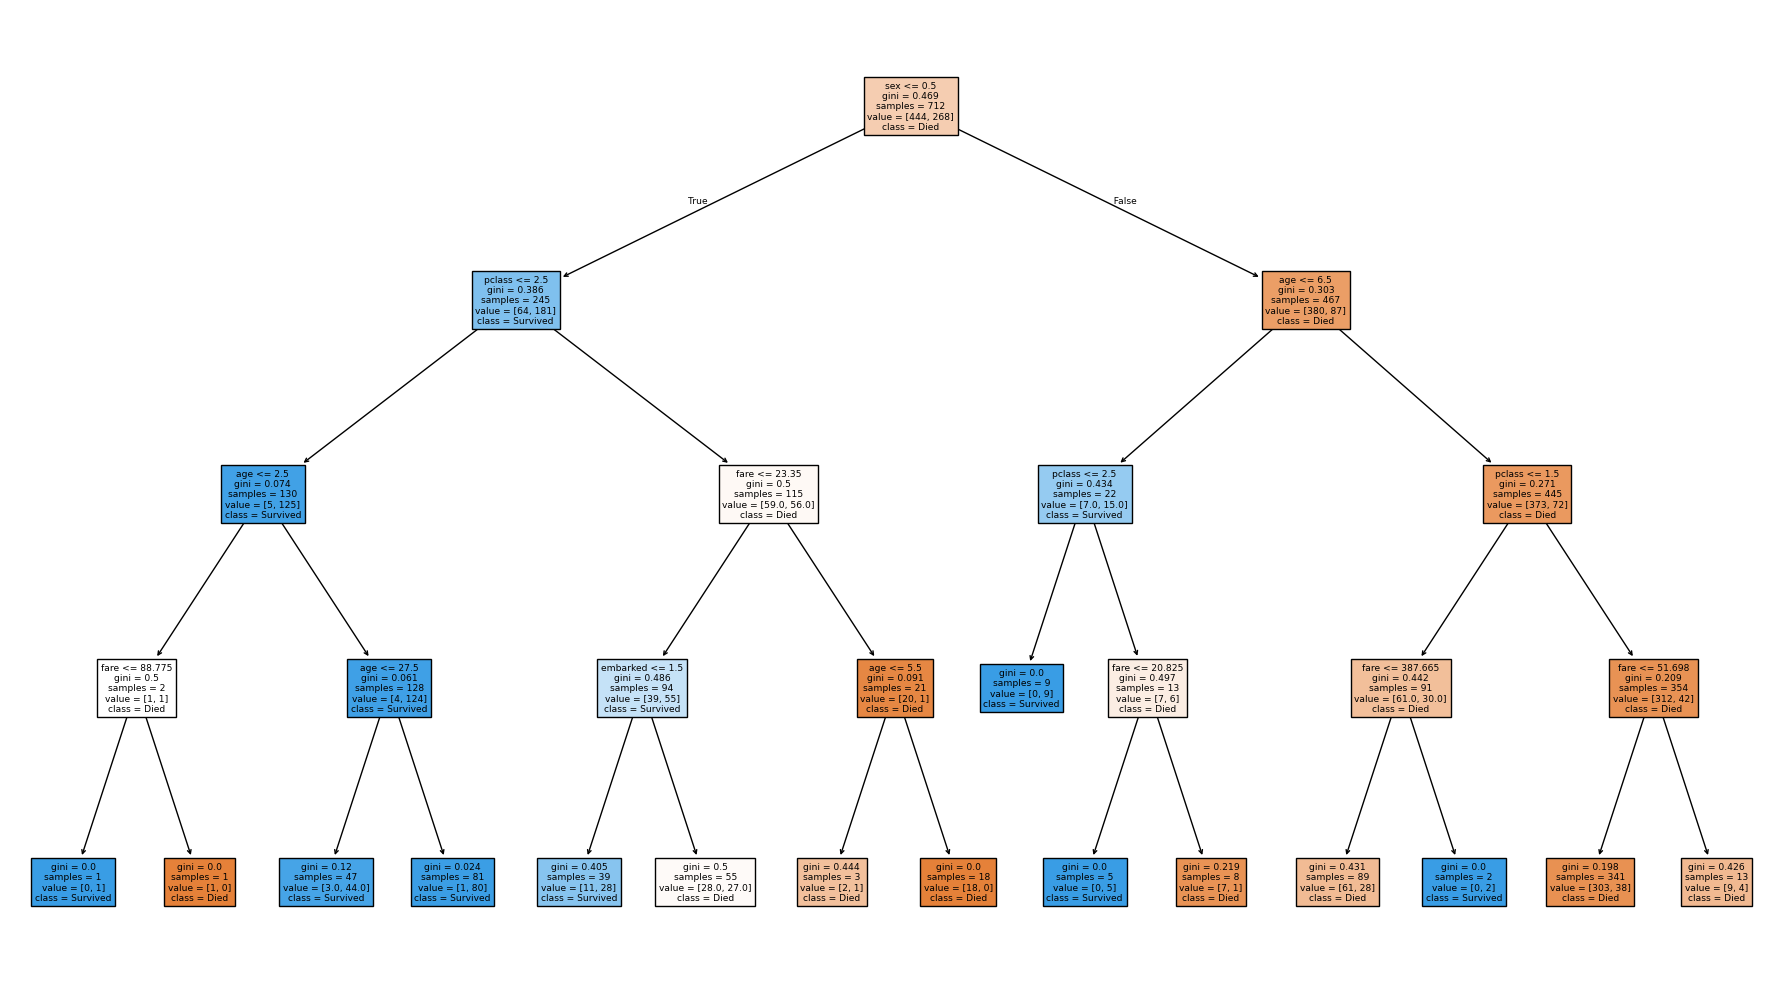

for depth =5 , accuracy=0.7988826815642458
for depth =6 , accuracy=0.7988826815642458
for depth =7 , accuracy=0.7932960893854749
for depth =8 , accuracy=0.7932960893854749
for depth =9 , accuracy=0.7988826815642458
for depth =10 , accuracy=0.7932960893854749


In [60]:
max_depth  = [1,2,3,4,5,6,7,8,9,10]
for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print(f"for depth ={depth} , accuracy={acc}")
    if depth == 4 :
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

for sample split =5 , accuracy=0.7988826815642458
for sample split =10 , accuracy=0.7988826815642458


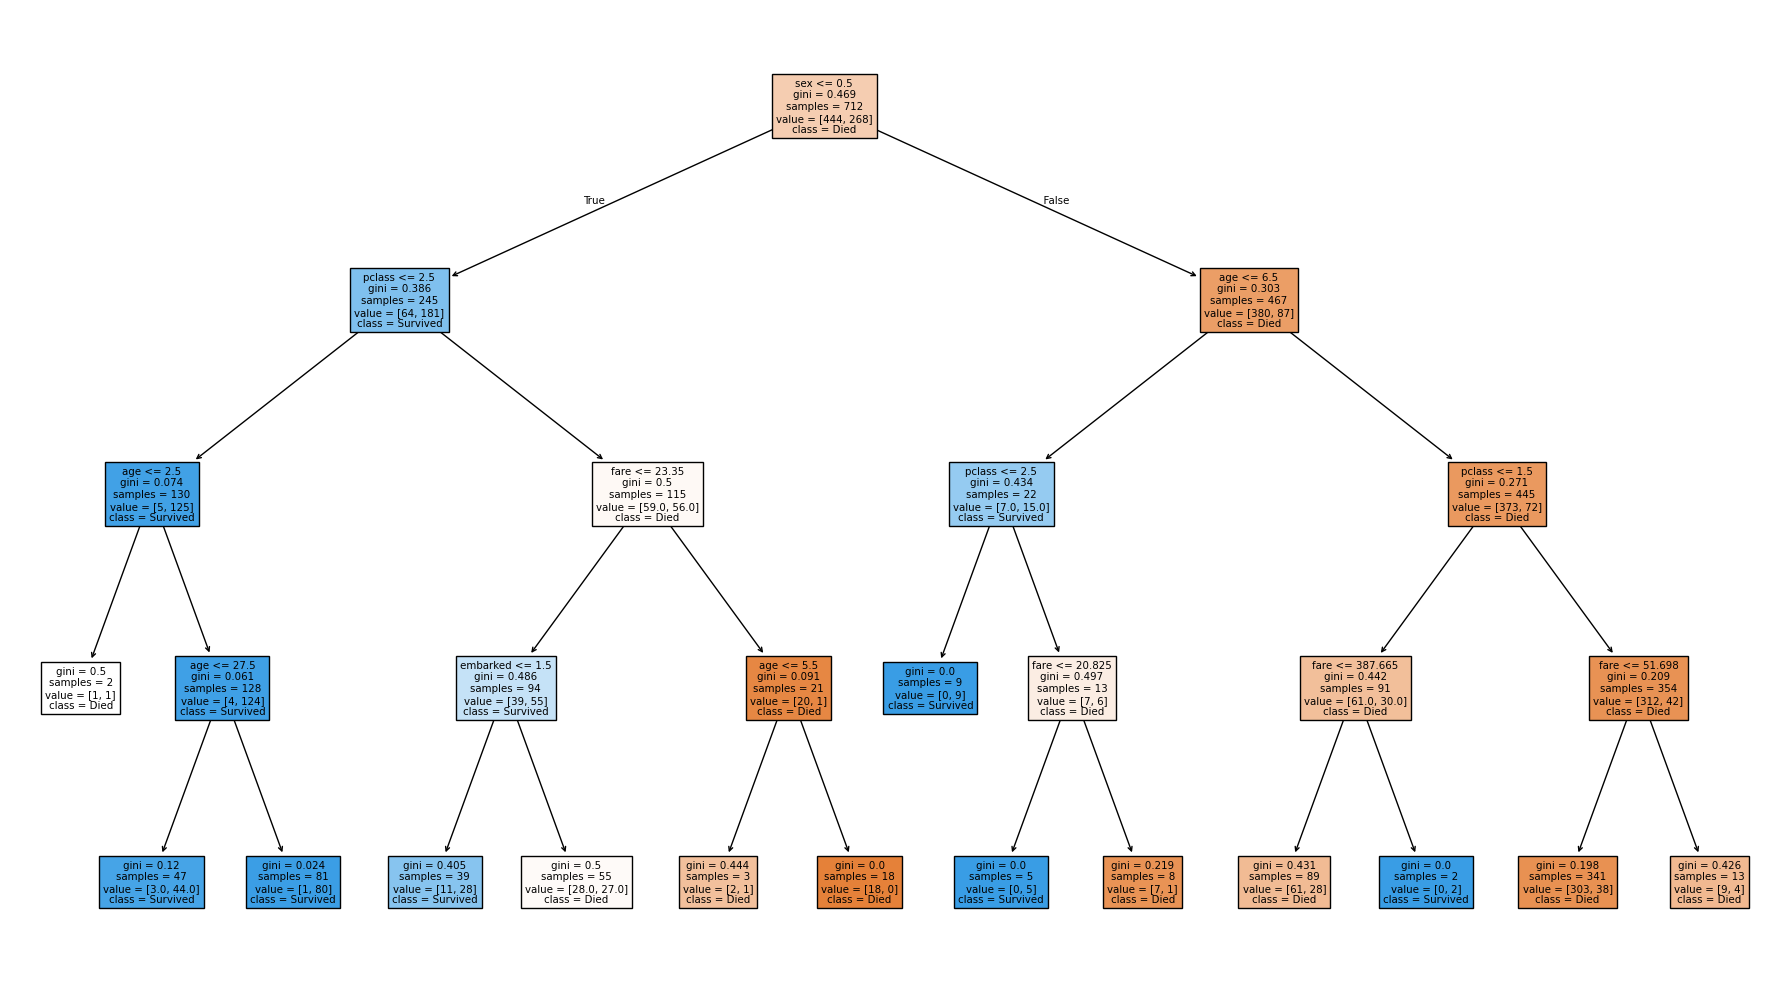

for sample split =15 , accuracy=0.7988826815642458
for sample split =20 , accuracy=0.7988826815642458
for sample split =25 , accuracy=0.7932960893854749
for sample split =30 , accuracy=0.7932960893854749


In [62]:
min_sample_splits = [5,10,15,20,25,30]
for split in min_sample_splits:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print(f"for sample split ={split} , accuracy={acc}")
    if split == 10 :
        plt.figure(figsize=(18,10))
        plot_tree(
            model,
            feature_names=X.columns,
            class_names=["Died","Survived"],
            filled=True
        )
        plt.tight_layout()
        plt.show()

## Decision Tree With post-Prunning

In [63]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
path= full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
#print(ccp_alphas)

In [76]:
# train our model for all alphas 
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42 , ccp_alpha = alpha)
    model.fit(X_train,y_train)
    trees.append((model,alpha))

In [77]:
best_acc = 0
best_alpha = 0

for model , alpha in trees :
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc :
        best_acc  = curr_acc
        best_alpha = alpha

In [78]:
print(best_alpha)
print(best_acc)

0.0015407231242023183
0.8379888268156425


In [108]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=12)
best_model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


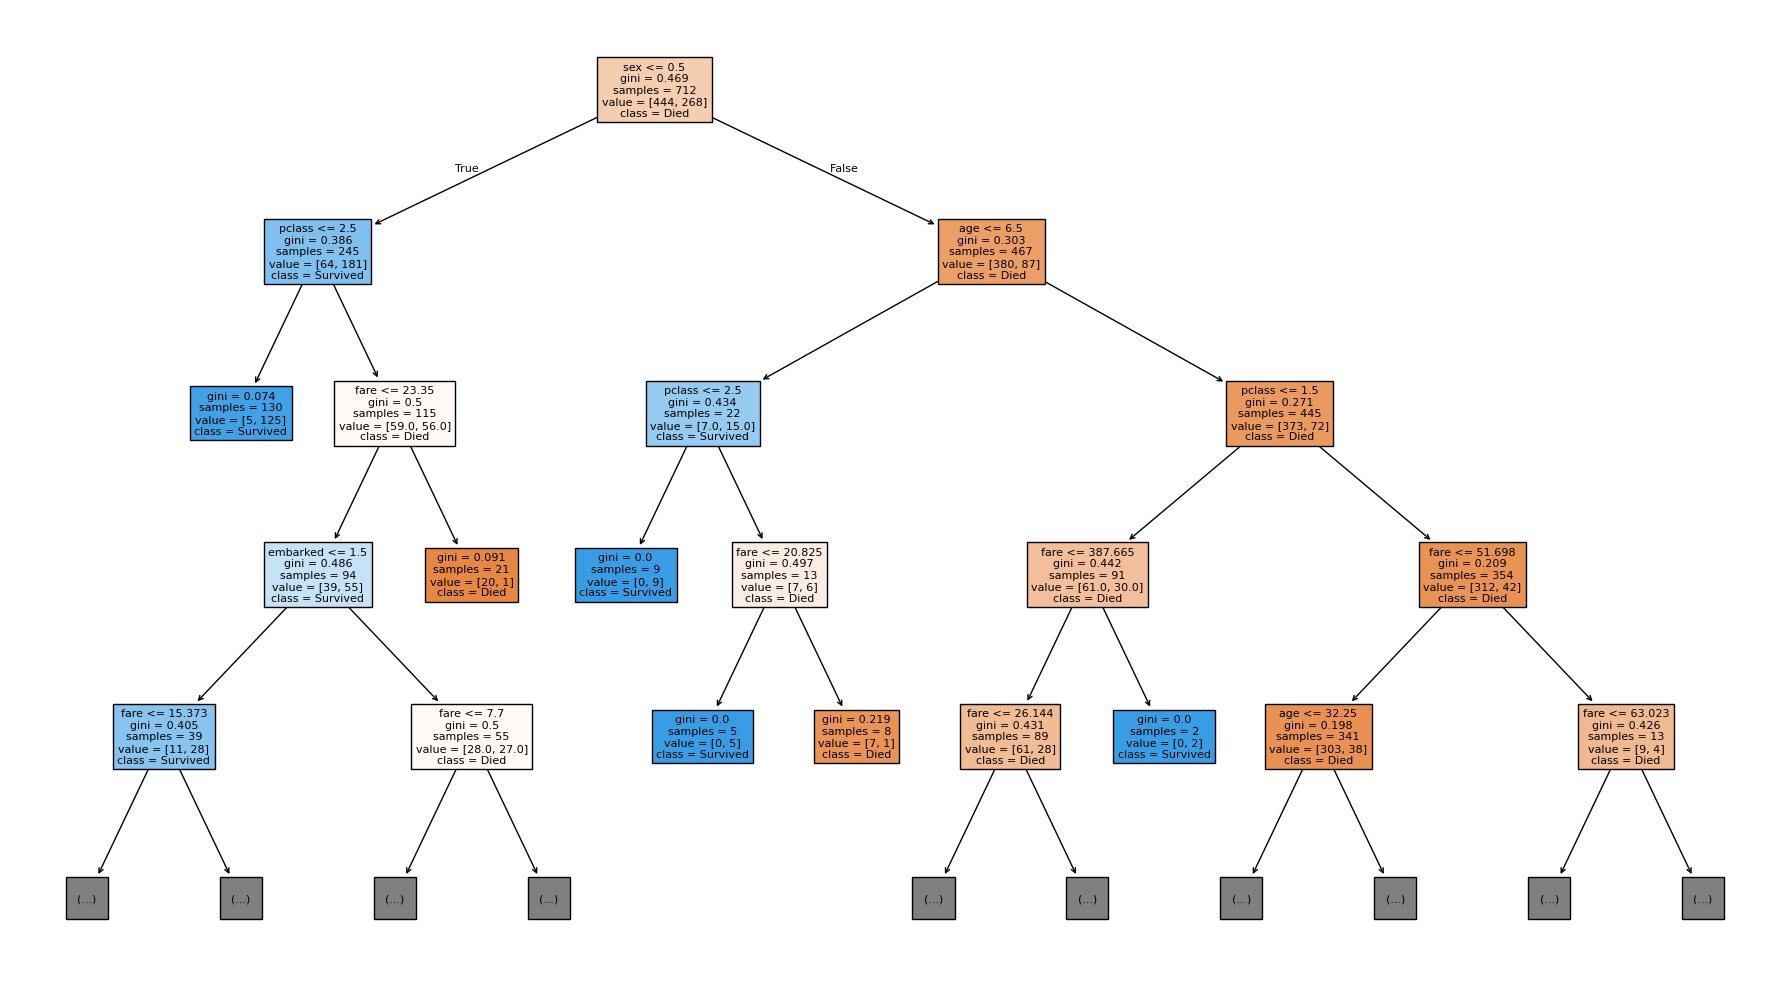

In [109]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True ,
    max_depth=4
)
plt.tight_layout()
plt.show()

In [110]:
print(best_model.score(X_test,y_test))

0.8435754189944135
